In [49]:
import pandas as pd


In [50]:
df = pd.read_csv("../data/raw/telco_churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [52]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [53]:
df['Churn'].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [54]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

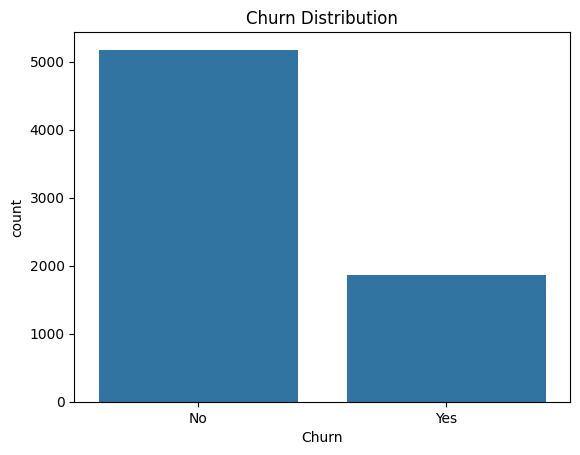

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


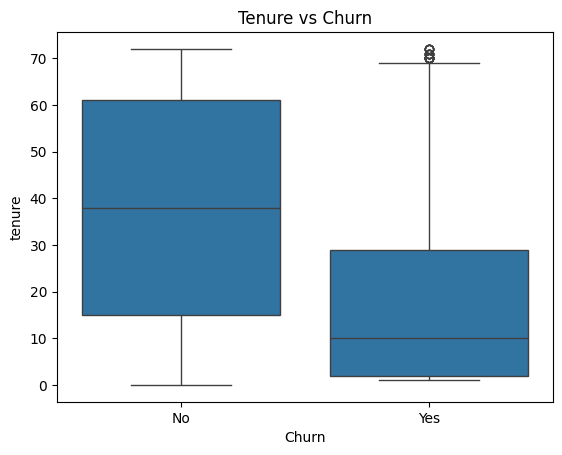

In [56]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


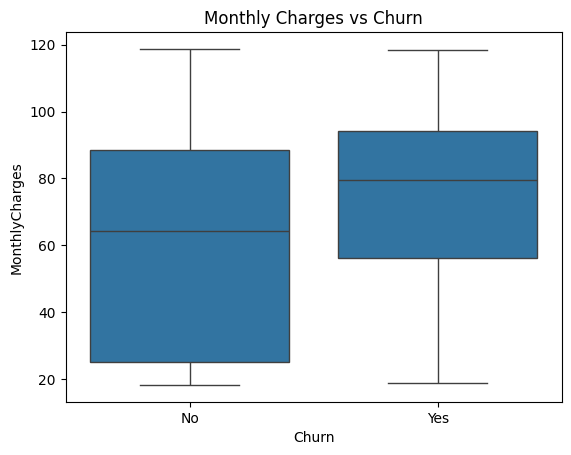

In [57]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


### Key EDA Observations
- Customers with lower tenure show higher churn rates.
- Higher monthly charges are associated with increased churn.
- Churn is an imbalanced classification problem.


In [58]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


C:\Users\prana\AppData\Local\Temp\ipykernel_19352\2576541415.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [59]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [60]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)


In [61]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns

categorical_cols, numerical_cols


(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object'))

In [62]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.shape


(7043, 31)

In [63]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [65]:
X_train.shape, X_test.shape
y_train.value_counts(), y_test.value_counts()


(Churn
 0    4139
 1    1495
 Name: count, dtype: int64,
 Churn
 0    1035
 1     374
 Name: count, dtype: int64)

In [66]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)


In [67]:
log_reg.fit(X_train, y_train)


C:\Users\prana\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [68]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]


In [69]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.8041163946061036

In [70]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)


array([[926, 109],
       [167, 207]])

In [71]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



### Baseline Model Observations
- Logistic Regression provides a reasonable baseline.
- Accuracy alone is misleading due to class imbalance.
- Recall for churn customers is low, which is risky for business.
- This motivates cost-sensitive optimization.


In [72]:
COST_FN = 10000   # Missed churn (customer leaves)
COST_FP = 500     # False alarm (unnecessary retention offer)


In [73]:
import numpy as np

def calculate_total_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    return total_cost


In [74]:
thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    cost = calculate_total_cost(y_test, y_pred_thresh)
    costs.append(cost)


In [75]:
optimal_index = np.argmin(costs)
optimal_threshold = thresholds[optimal_index]
optimal_threshold


np.float64(0.1)

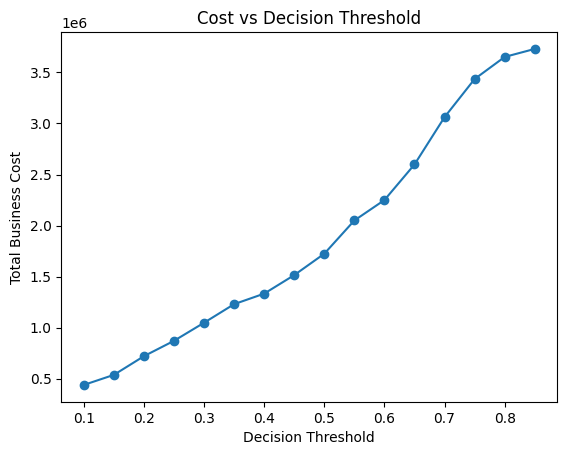

In [76]:
import matplotlib.pyplot as plt

plt.plot(thresholds, costs, marker='o')
plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost")
plt.title("Cost vs Decision Threshold")
plt.show()


In [77]:
y_pred_opt = (y_prob >= optimal_threshold).astype(int)

confusion_matrix(y_test, y_pred_opt)
print(classification_report(y_test, y_pred_opt))


              precision    recall  f1-score   support

           0       0.97      0.50      0.66      1035
           1       0.41      0.95      0.57       374

    accuracy                           0.62      1409
   macro avg       0.69      0.73      0.61      1409
weighted avg       0.82      0.62      0.63      1409



### Cost-Sensitive Learning Insights
- Standard accuracy-based thresholds are not optimal for churn prediction.
- Assigning higher cost to false negatives significantly improves churn recall.
- The optimal threshold minimizes total business loss rather than classification error.


In [78]:
segmentation_features = df[['tenure', 'MonthlyCharges', 'TotalCharges']]


In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
segmentation_scaled = scaler.fit_transform(segmentation_features)


In [80]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 6)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(segmentation_scaled)
    inertia.append(kmeans.inertia_)


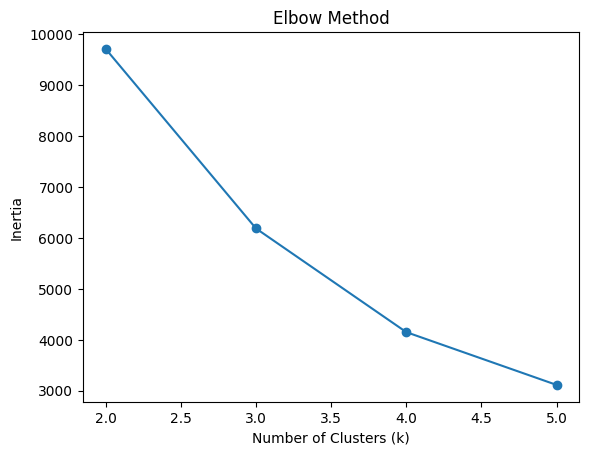

In [81]:
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [82]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment'] = kmeans.fit_predict(segmentation_scaled)


In [83]:
df.groupby('Segment')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()


,tenure,MonthlyCharges,TotalCharges
Segment,,,
0,13.267164,75.073619,1036.212771
1,58.572273,89.672432,5245.974864
2,29.392048,26.648151,810.608414


In [84]:
df.groupby('Segment')['Churn'].mean()


Segment
0    0.470896
1    0.153636
2    0.124364
Name: Churn, dtype: float64

### Segmentation Insights
- Customers can be grouped into distinct behavioral segments.
- Churn rates differ significantly across segments.
- Retention strategies should be segment-specific.
